In [61]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Get project root
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

%load_ext autoreload
%autoreload 2

import utils.visualization_utils as visualization_utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
customer_data = pd.read_csv("../data/customer_profiles.csv")
synth_data = pd.read_csv("../data/synthetic_fraud_transactions.csv")
terminal_data = pd.read_csv("../data/terminal_profiles.csv")

print("Customer Data")
display(customer_data.head())

print("Synthetic Data")
display(synth_data.head())

print("Terminal Data")
display(terminal_data.head())

Customer Data


,CUSTOMER_ID,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,nb_terminals
0,0,54.881350,71.518937,62.262521,31.131260,2.179533,78
1,1,42.365480,64.589411,46.570785,23.285393,3.567092,85
2,2,96.366276,38.344152,80.213879,40.106939,2.115580,70
3,3,56.804456,92.559664,11.748426,5.874213,0.348517,70
4,4,2.021840,83.261985,78.924891,39.462446,3.480049,65


Synthetic Data


,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0


Terminal Data


,TERMINAL_ID,x_terminal_id,y_terminal_id
0,0,41.702200,72.032449
1,1,0.011437,30.233257
2,2,14.675589,9.233859
3,3,18.626021,34.556073
4,4,39.676747,53.881673


In [4]:
# Combine synth_data and customer_data
synth_customer_df = pd.merge(customer_data, synth_data, on='CUSTOMER_ID')

# Combine terminal data and synthetic transactions per customer data
fraud_df = pd.merge(terminal_data, synth_customer_df, on='TERMINAL_ID')

display(fraud_df.head())

,TERMINAL_ID,x_terminal_id,y_terminal_id,CUSTOMER_ID,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,nb_terminals,TRANSACTION_ID,TX_DATETIME,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,41.7022,72.032449,399,45.265353,71.371776,91.963727,45.981863,0.586335,76,1268009,2018-08-11 08:26:45,131.89,11435205,132,0,0
1,0,41.7022,72.032449,504,46.185344,72.624328,50.112812,25.056406,3.616203,71,453128,2018-05-18 07:20:47,83.96,4087247,47,0,0
2,0,41.7022,72.032449,504,46.185344,72.624328,50.112812,25.056406,3.616203,71,730636,2018-06-16 07:23:29,28.95,6593009,76,0,0
3,0,41.7022,72.032449,504,46.185344,72.624328,50.112812,25.056406,3.616203,71,784163,2018-06-21 15:51:38,71.86,7055498,81,0,0
4,0,41.7022,72.032449,504,46.185344,72.624328,50.112812,25.056406,3.616203,71,1025453,2018-07-16 20:07:06,55.44,9230826,106,0,0


## EDA On Full Dataset

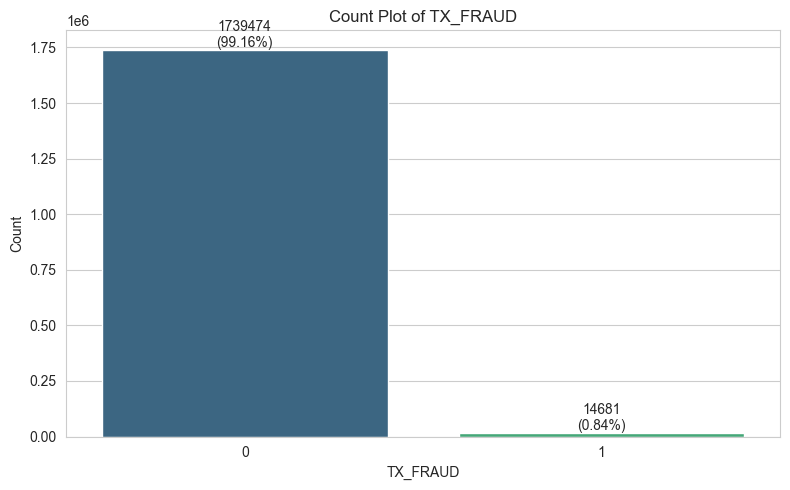

In [6]:
# count of fraudlant and legtimate transactions
visualization_utils.plot_count(fraud_df, "TX_FRAUD", show_percentage=True)

### What is the total amount lost to fraud and the average value of fraudulent transactions compared to legitimate ones?

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



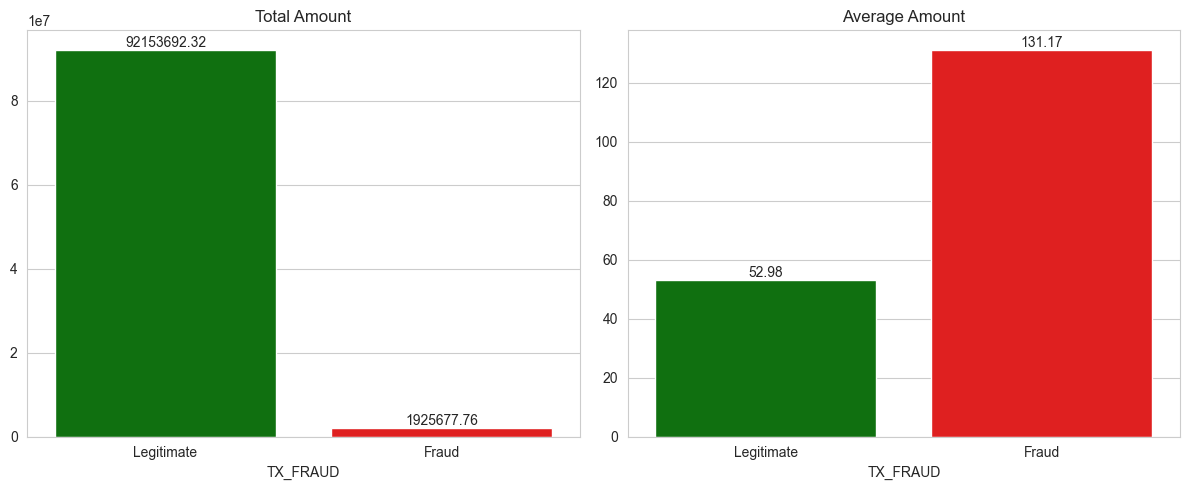

In [7]:
visualization_utils.plot_fraud_financial_impact(fraud_df, "TX_AMOUNT", "TX_FRAUD")

#### Fraud Distribution Over Time (by Day)

In [8]:
# ensuring that the TX_DATETIME is datetime data type
fraud_df['TX_DATETIME'] = pd.to_datetime(fraud_df['TX_DATETIME'])

In [10]:
fraud_df['day'] = fraud_df['TX_DATETIME'].dt.day

# day name
fraud_df['day_name'] = fraud_df['TX_DATETIME'].dt.day_name()

In [12]:
fraud_df[["TX_DATETIME", "day", "day_name"]].head()

,TX_DATETIME,day,day_name
0,2018-08-11 08:26:45,11,Saturday
1,2018-05-18 07:20:47,18,Friday
2,2018-06-16 07:23:29,16,Saturday
3,2018-06-21 15:51:38,21,Thursday
4,2018-07-16 20:07:06,16,Monday


In [16]:
fraud_by_day = fraud_df.groupby('day')['TX_FRAUD'].sum().reset_index()
fraud_by_day.columns = ['day', 'fraud_count']

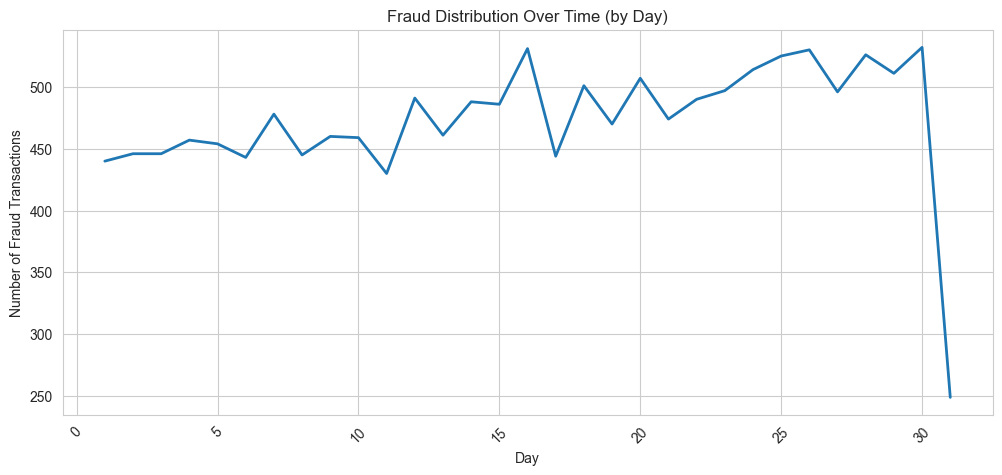

In [27]:
visualization_utils.plot_fraud_over_time(fraud_by_day, 
                                         "day", 
                                         "fraud_count", 
                                         title="Fraud Distribution", 
                                         y_label="Number of Fraud Transactions")

In [ ]:
fraud_amount_by_day = fraud_df.groupby('day')['TX_AMOUNT'].sum().reset_index()
fraud_amount_by_day.columns = ['day', 'fraud_amount']

fraud_amount_by_day.head()

,day,fraud_amount
0,1,3075349.97
1,2,3076436.80
2,3,3118501.62
3,4,3093393.93
4,5,3075091.96


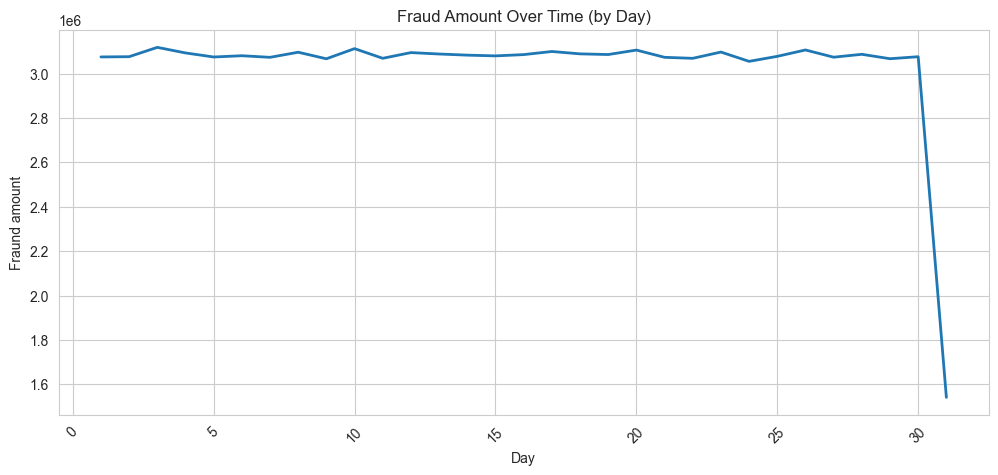

In [28]:
visualization_utils.plot_fraud_over_time(fraud_amount_by_day, 
                                         "day", 
                                         "fraud_amount",
                                         title="Fraud Amount",
                                         y_label="Fraund amount")

#### Behavorial Pattern Across Days

In [31]:
fraud_df["day_name"] = fraud_df["TX_DATETIME"].dt.day_name()

fraud_df["day_of_week"] = fraud_df["TX_DATETIME"].dt.dayofweek  # 0=Monday

fraud_df["is_weekend"] = fraud_df["day_of_week"].isin([5, 6]).astype(int)

<string>:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


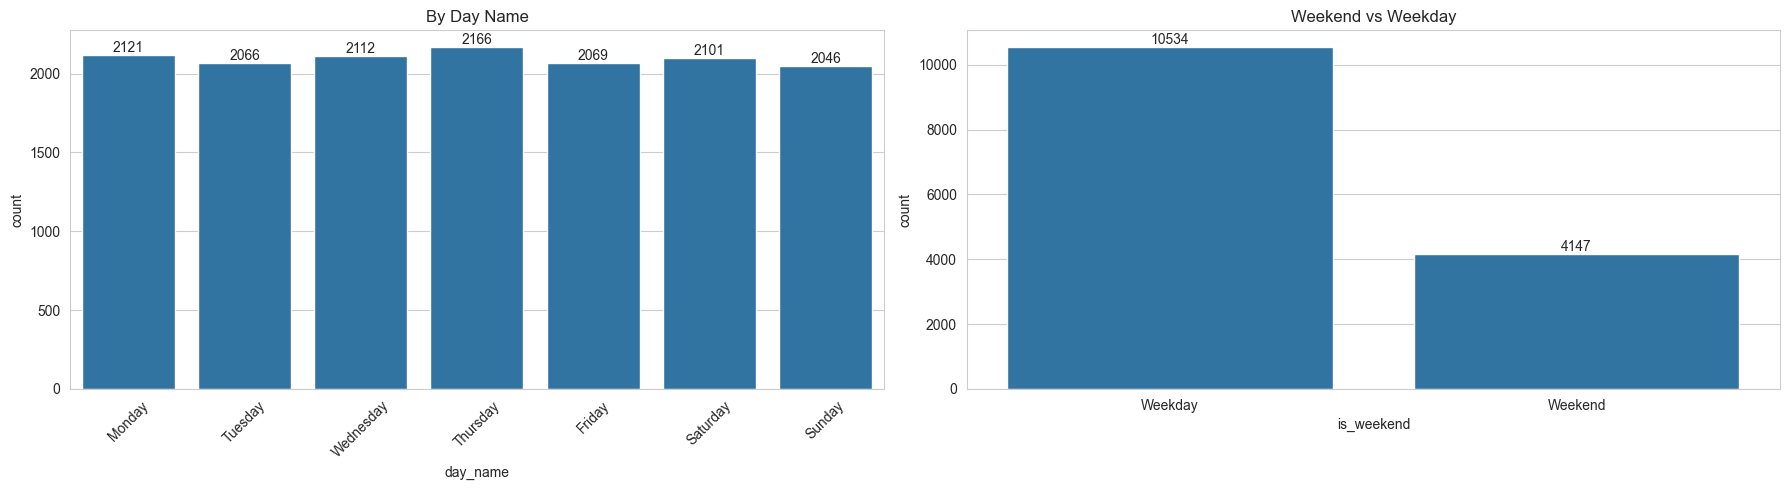

In [34]:
visualization_utils.plot_time_fraud_patterns(fraud_df, target_col="TX_FRAUD")

<string>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


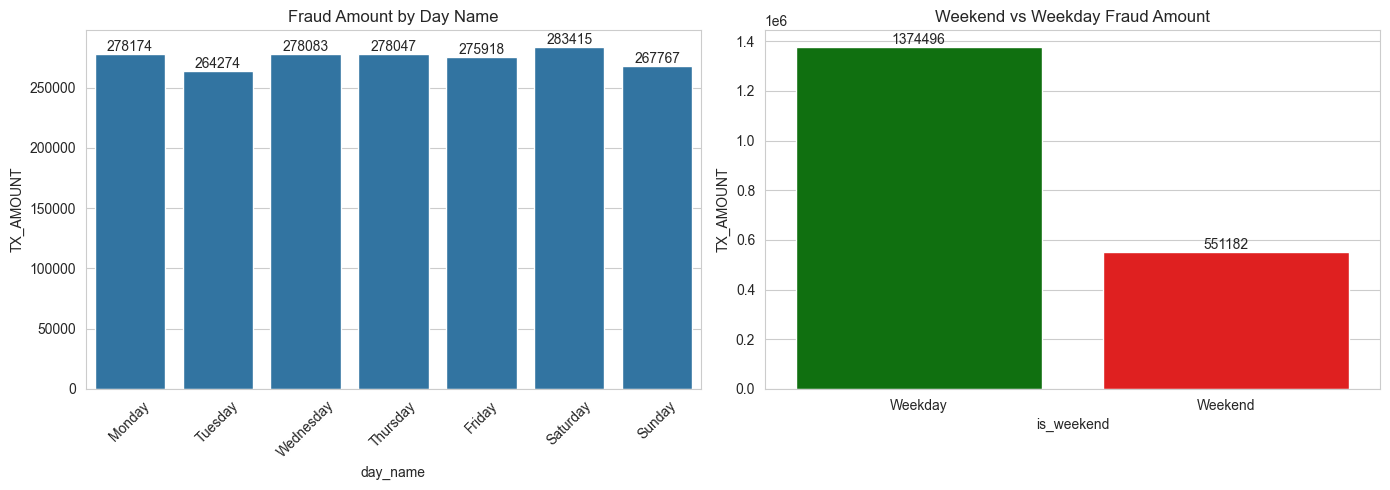

In [38]:
visualization_utils.plot_fraud_amount_time_patterns(fraud_df, 
                                                    target_col="TX_FRAUD",
                                                    amount_col="TX_AMOUNT")

#### Fraudlant Transactions across day hours

In [49]:
fraud_df["tx_hour"] = pd.to_datetime(fraud_df["TX_DATETIME"]).dt.hour

fraud_df["tx_hour"].head()

0     8
1     7
2     7
3    15
4    20
Name: tx_hour, dtype: int32

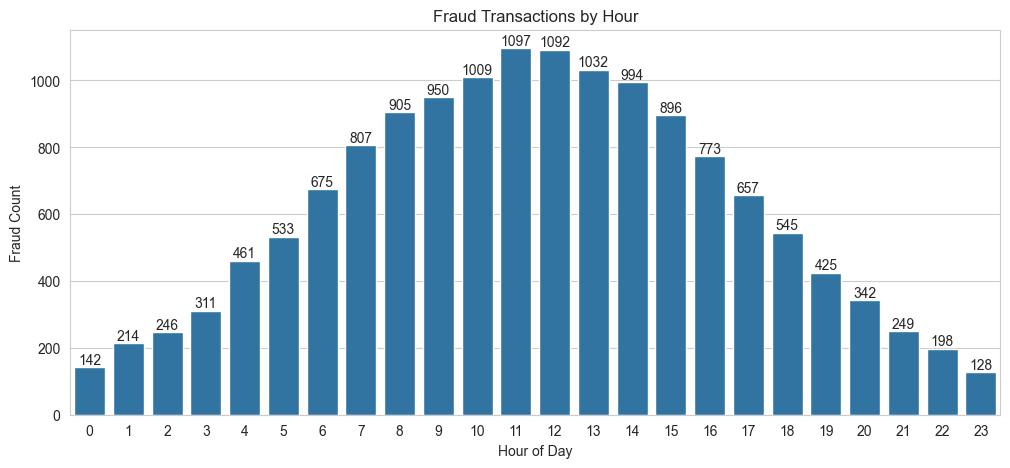

In [50]:
visualization_utils.plot_fraud_transactions_across_day(fraud_df, 
                                                       target_col="TX_FRAUD",
                                                       time_col="tx_hour")

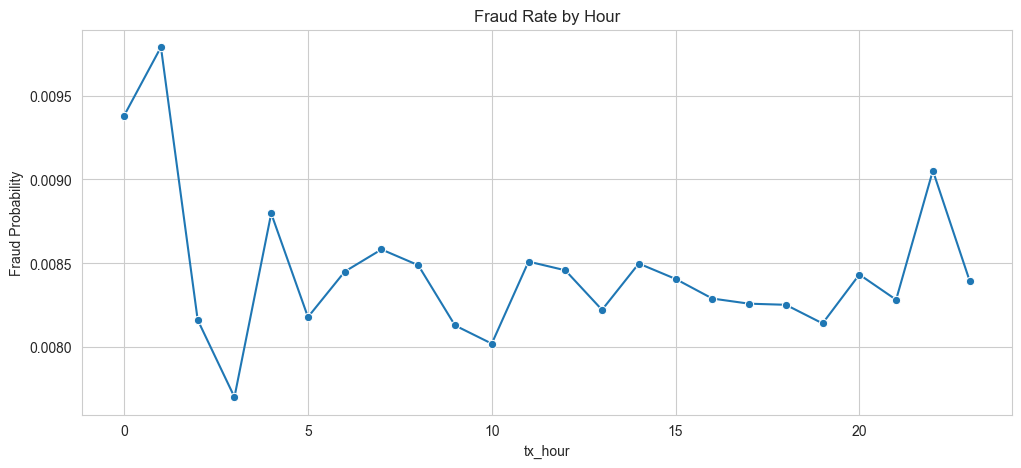

In [52]:
# fraud rate by hour
hourly_rate = (
    fraud_df.groupby("tx_hour")["TX_FRAUD"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly_rate,
    x="tx_hour",
    y="TX_FRAUD",
    marker="o"
)

plt.title("Fraud Rate by Hour")
plt.ylabel("Fraud Probability")
plt.show()

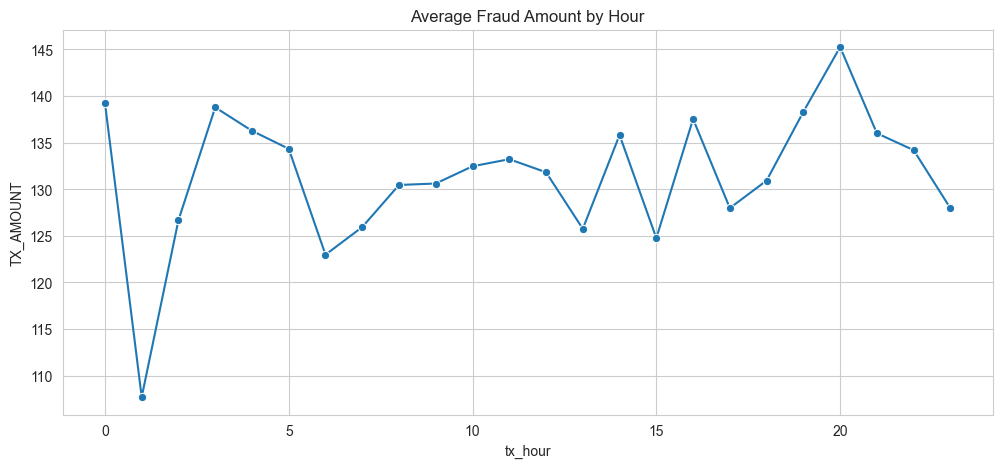

In [ ]:
# average fraud amount consumed by hour

fraud_only = fraud_df[fraud_df["TX_FRAUD"] == 1]

hourly_amount = (
    fraud_only.groupby("tx_hour")["TX_AMOUNT"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly_amount,
    x="tx_hour",
    y="TX_AMOUNT",
    marker="o"
)

plt.title("Average Fraud Amount by Hour")
plt.show()

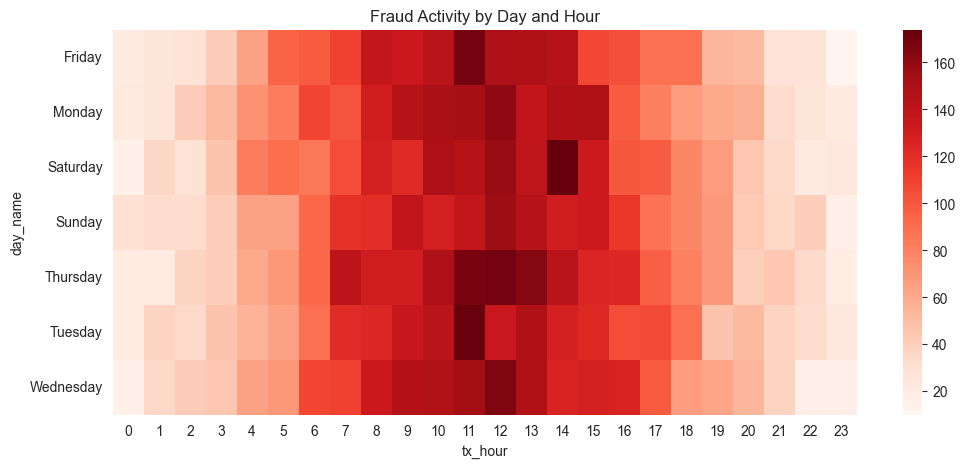

In [62]:
pivot = pd.pivot_table(
    fraud_df[fraud_df["TX_FRAUD"] == 1],
    values="TX_AMOUNT",
    index="day_name",
    columns="tx_hour",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot,
    cmap="Reds"
)

plt.title("Fraud Activity by Day and Hour")
plt.show()

#### Geographical Insights

In [67]:
fraud_df["customer_terminal_distance"] = np.sqrt(
    (fraud_df["x_customer_id"] - fraud_df["x_terminal_id"])**2 +
    (fraud_df["y_customer_id"] - fraud_df["y_terminal_id"])**2
)

fraud_df[["customer_terminal_distance", "TX_FRAUD"]].head()

,customer_terminal_distance,TX_FRAUD
0,3.623885,0
1,4.522046,0
2,4.522046,0
3,4.522046,0
4,4.522046,0


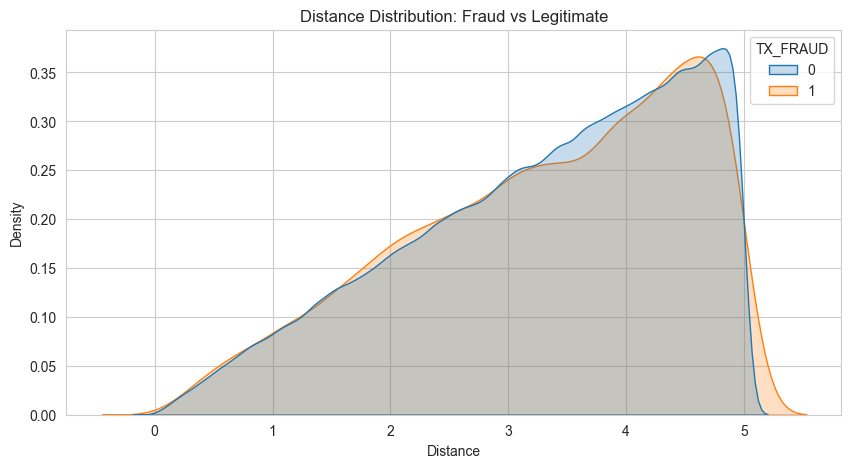

In [69]:
plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=fraud_df,
    x="customer_terminal_distance",
    hue="TX_FRAUD",
    fill=True,
    common_norm=False
)

plt.title("Distance Distribution: Fraud vs Legitimate")
plt.xlabel("Distance")
plt.show()

#### Fraud Rate by Distance Bucket

In [83]:
fraud_df["distance_bucket"] = pd.qcut(
    fraud_df["customer_terminal_distance"],
    q=10,
    duplicates="drop"
)

fraud_rate = (
    fraud_df
    .groupby("distance_bucket")["TX_FRAUD"]
    .mean()
    .reset_index()
)

fraud_rate["TX_FRAUD_pct"] = fraud_rate["TX_FRAUD"] * 100

fraud_rate

,distance_bucket,TX_FRAUD,TX_FRAUD_pct
0,"(0.010599999999999998, 1.545]",0.008494,0.849380
1,"(1.545, 2.199]",0.008819,0.881914
2,"(2.199, 2.701]",0.008483,0.848274
3,"(2.701, 3.129]",0.008437,0.843718
4,"(3.129, 3.507]",0.008084,0.808373
5,"(3.507, 3.848]",0.007308,0.730830
6,"(3.848, 4.164]",0.008334,0.833433
7,"(4.164, 4.459]",0.008483,0.848293
8,"(4.459, 4.737]",0.008545,0.854525
9,"(4.737, 5.0]",0.008705,0.870532


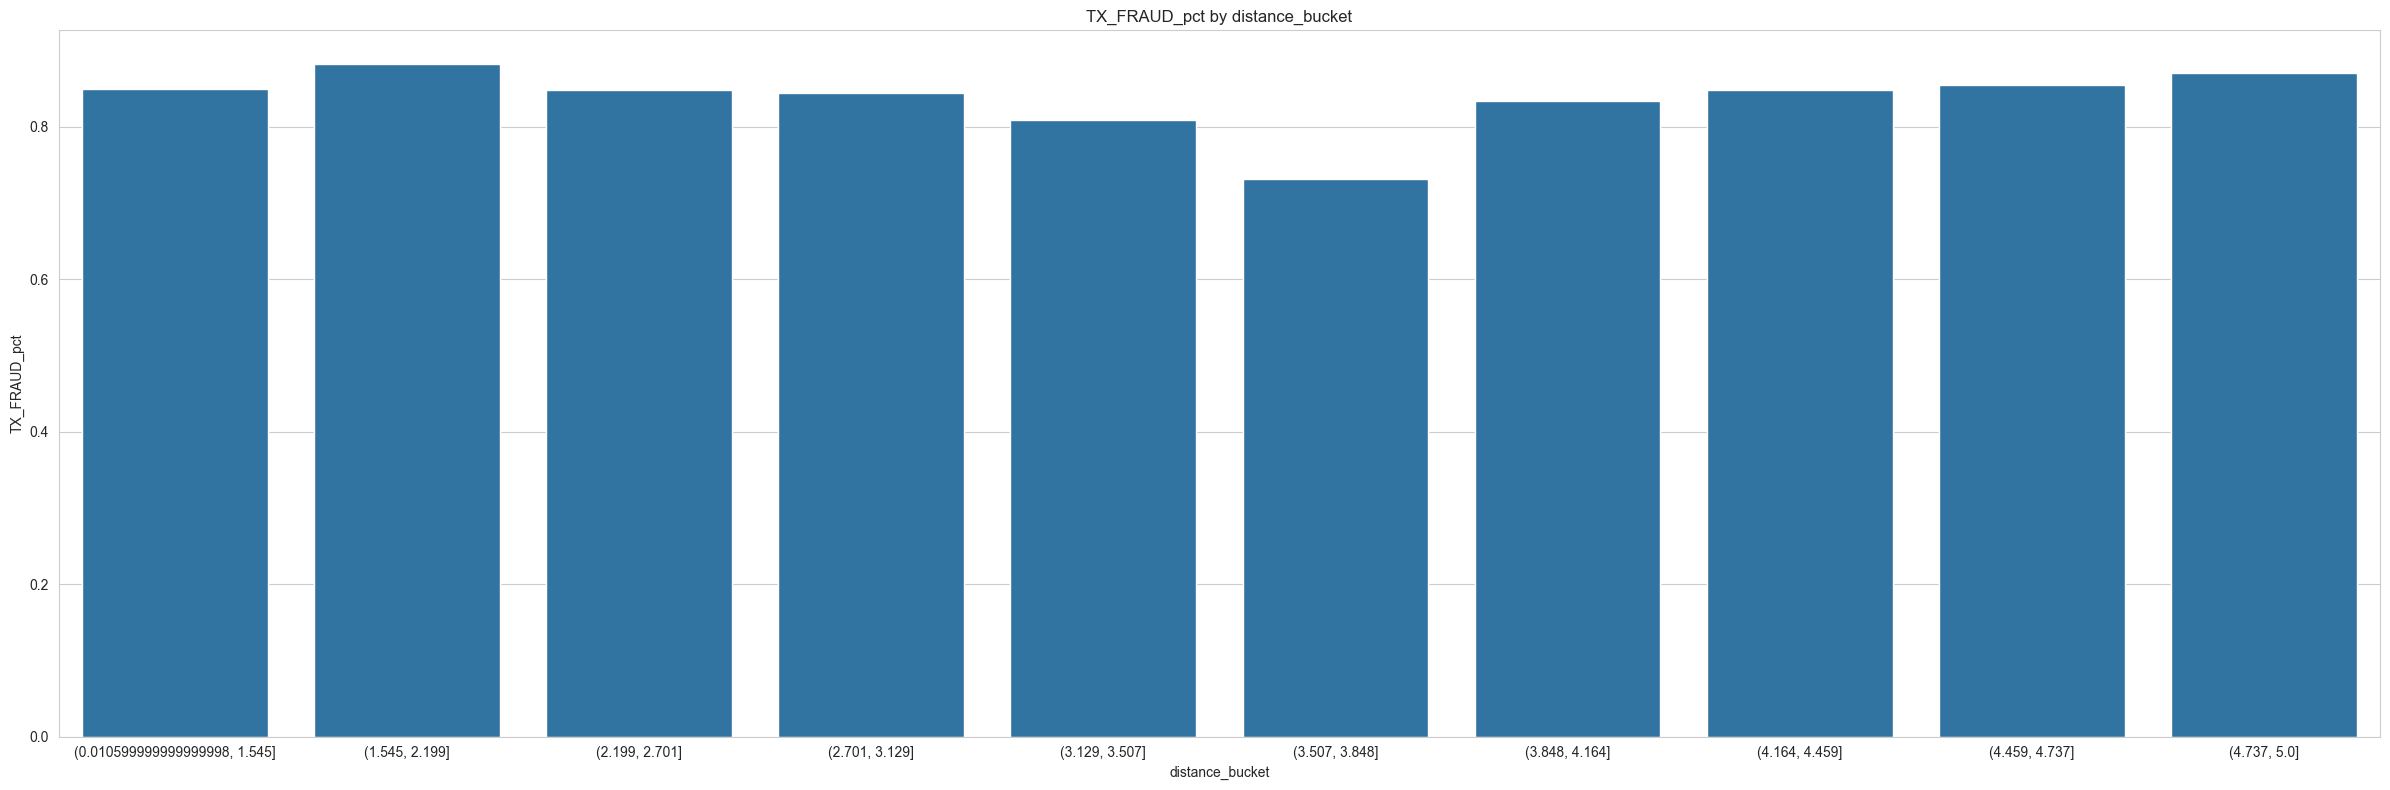

In [81]:
visualization_utils.plot_bar(df=fraud_rate,
                             x="distance_bucket",
                             y="TX_FRAUD_pct",
                             figsize=(24, 8))

#### Fraud Rate by Deviation Amount

In [84]:
# Amount deviation from customer's norm
fraud_df["amount_zscore"] = (fraud_df["TX_AMOUNT"] - fraud_df["mean_amount"]) / (fraud_df["std_amount"] + 1e-9)

In [96]:
fraud_df["zscore_bucket"] = pd.qcut(
    fraud_df["amount_zscore"],
    q=10,
    duplicates="drop"
)

fraud_rate = (
    fraud_df
    .groupby("zscore_bucket")["TX_FRAUD"]
    .mean()
    .reset_index()
)

fraud_rate["TX_FRAUD_pct"] = fraud_rate["TX_FRAUD"] * 100

fraud_rate

,zscore_bucket,TX_FRAUD,TX_FRAUD_pct
0,"(-2.001, -1.182]",0.005410,0.541000
1,"(-1.182, -0.784]",0.005222,0.522190
2,"(-0.784, -0.482]",0.005370,0.537009
3,"(-0.482, -0.219]",0.005359,0.535872
4,"(-0.219, 0.0303]",0.005535,0.553541
5,"(0.0303, 0.283]",0.005478,0.547844
6,"(0.283, 0.553]",0.005621,0.562096
7,"(0.553, 0.872]",0.005239,0.523897
8,"(0.872, 1.319]",0.005439,0.543853
9,"(1.319, 79.922]",0.035020,3.501961


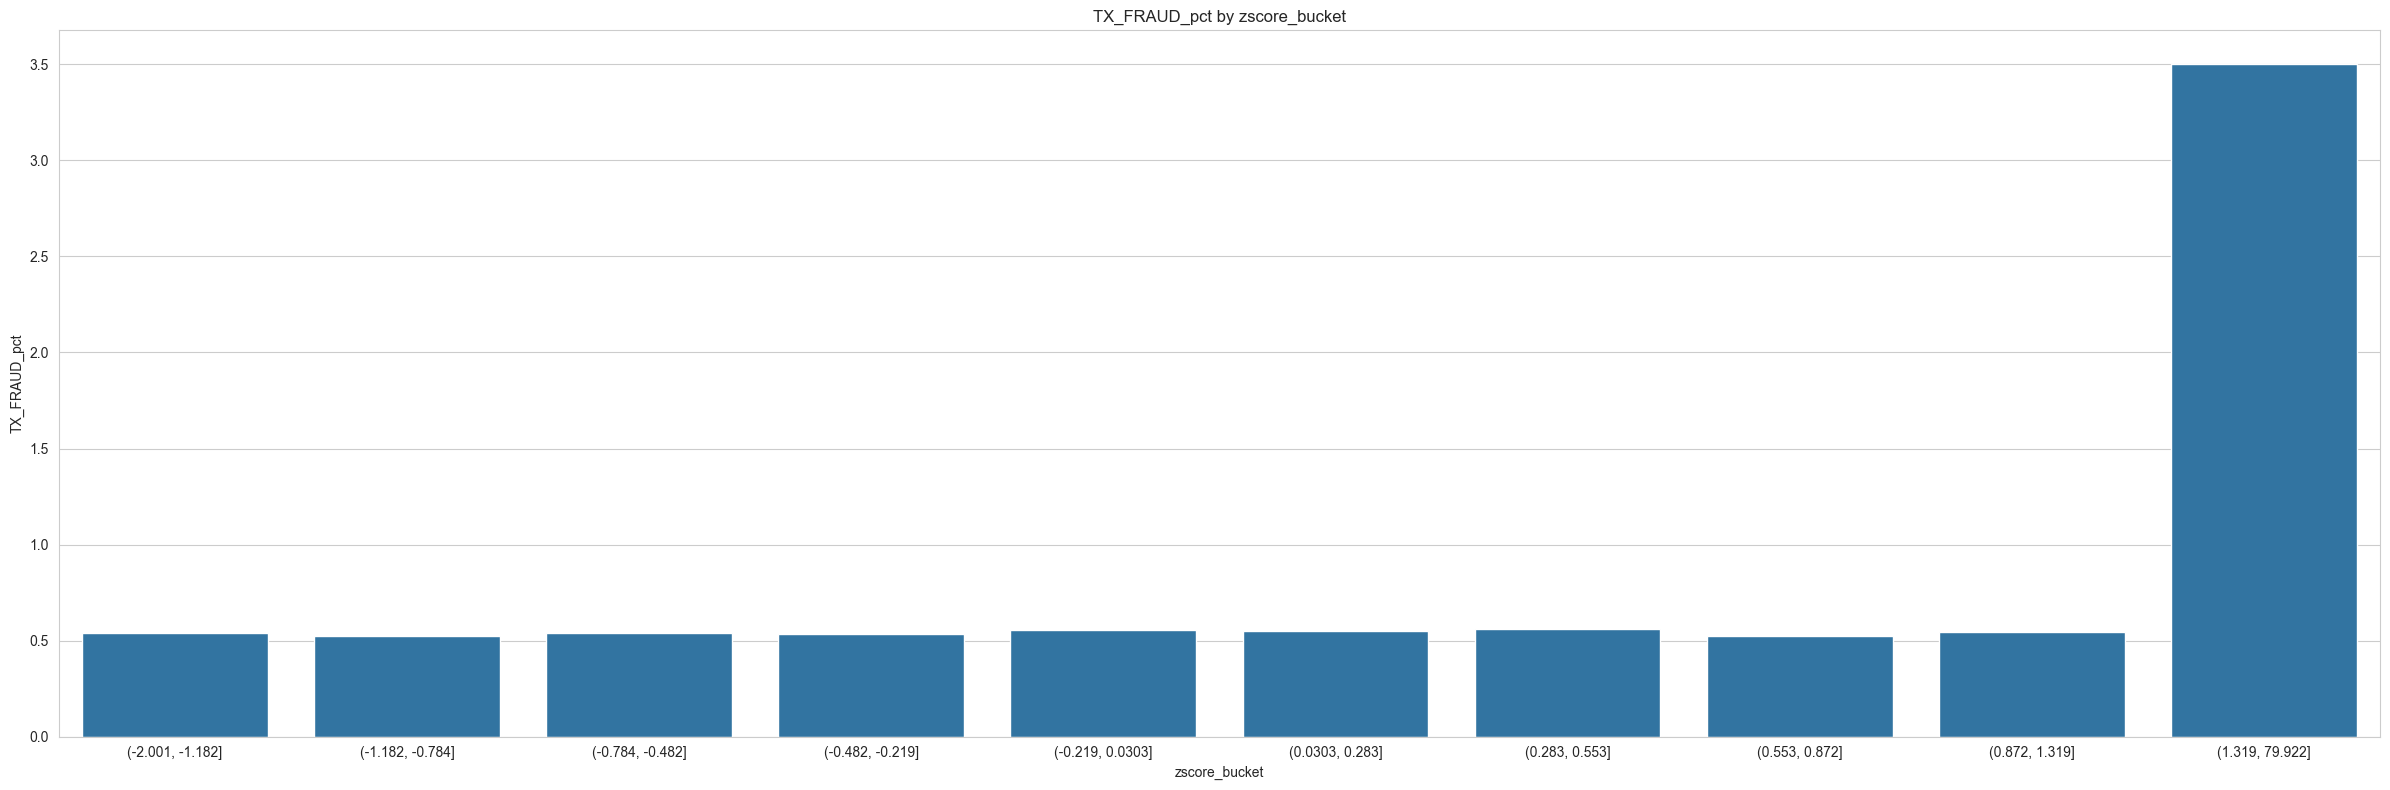

In [97]:
visualization_utils.plot_bar(df=fraud_rate,
                             x="zscore_bucket",
                             y="TX_FRAUD_pct",
                             figsize=(24, 8))

#### Customer's average spending level

In [98]:
# Is this transaction above the customer's typical amount?
fraud_df["amount_above_mean"] = (fraud_df["TX_AMOUNT"] > fraud_df["mean_amount"]).astype(int)

fraud_df[["TX_AMOUNT", "mean_amount", "amount_above_mean"]].head()

,TX_AMOUNT,mean_amount,amount_above_mean
0,131.89,91.963727,1
1,83.96,50.112812,1
2,28.95,50.112812,0
3,71.86,50.112812,1
4,55.44,50.112812,1


C:\Users\LAP X\AppData\Local\Temp\ipykernel_33892\1909953875.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\LAP X\AppData\Local\Temp\ipykernel_33892\1909953875.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Below/Equal Avg", "Above Avg"])


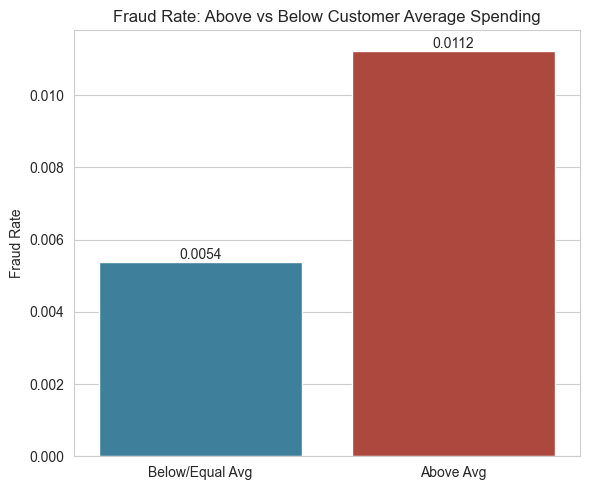

In [99]:
rate_df = (
    fraud_df.groupby("amount_above_mean")["TX_FRAUD"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=rate_df,
    x="amount_above_mean",
    y="TX_FRAUD",
    palette=["#2E86AB", "#C0392B"]
)

ax.set_xticklabels(["Below/Equal Avg", "Above Avg"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f")

plt.title("Fraud Rate: Above vs Below Customer Average Spending")
plt.xlabel("")
plt.ylabel("Fraud Rate")

plt.tight_layout()
plt.show()

#### Fraudlent Distribution

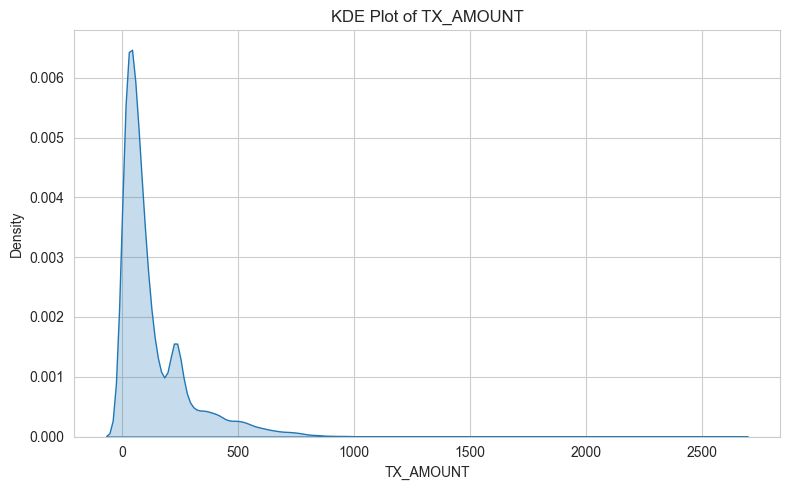

In [70]:
visualization_utils.plot_kde(fraud_only, "TX_AMOUNT")

#### Relationship between features

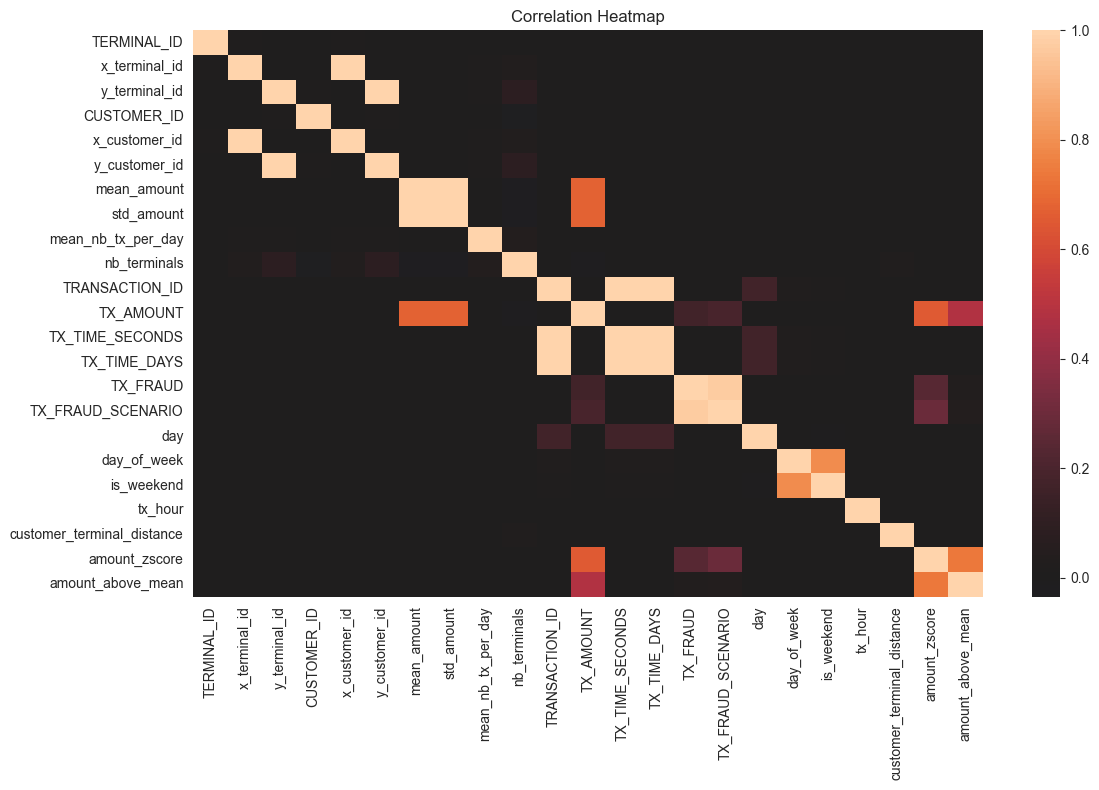

In [101]:
visualization_utils.plot_correlation_heatmap(fraud_df)

In [102]:
def find_highly_correlated_features(
    df,
    threshold=0.95
):
    """
    Find feature pairs whose absolute correlation exceeds threshold.

    Parameters
    ----------
    df : pd.DataFrame
    threshold : float
        Correlation threshold.

    Returns
    -------
    correlated_pairs : pd.DataFrame
        Feature pairs and their correlations.
    """

    numeric_df = df.select_dtypes(include=np.number)

    corr_matrix = numeric_df.corr().abs()

    # Keep only upper triangle
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    correlated_pairs = []

    for col in upper_triangle.columns:
        for row in upper_triangle.index:
            corr_value = upper_triangle.loc[row, col]

            if pd.notna(corr_value) and corr_value >= threshold:
                correlated_pairs.append(
                    {
                        "feature_1": row,
                        "feature_2": col,
                        "correlation": corr_value
                    }
                )

    correlated_pairs = pd.DataFrame(
        correlated_pairs
    ).sort_values(
        "correlation",
        ascending=False
    )

    return correlated_pairs

In [103]:
high_corr_pairs = find_highly_correlated_features(
    fraud_df,
    threshold=0.95
)

high_corr_pairs

,feature_1,feature_2,correlation
2,mean_amount,std_amount,1.000000
3,TRANSACTION_ID,TX_TIME_SECONDS,0.999999
5,TX_TIME_SECONDS,TX_TIME_DAYS,0.999992
4,TRANSACTION_ID,TX_TIME_DAYS,0.999985
0,x_terminal_id,x_customer_id,0.996332
1,y_terminal_id,y_customer_id,0.996299
6,TX_FRAUD,TX_FRAUD_SCENARIO,0.969587


Columns to drop:

    - std_amount
    - TX_TIME_SECONDS
    - TRANSACTION_ID
    - Raw Coordinates but after considering the distance between the **customer and the terminal**
    - TX_FRAUD_SCENARIO and we can experiment with and without it

In [ ]:
# extract features that are correlated with the target class
def categorize_features_by_correlation(
    df,
    target_col,
    perfect_threshold=0.99,
    moderate_threshold=0.3,
    no_corr_threshold=0.05
):
    """
    Categorize features according to their correlation with the target.

    Returns:
        perfect_corr_features
        moderate_corr_features
        no_corr_features
        correlations_df
    """

    # Numerical columns only
    numeric_df = df.select_dtypes(include=np.number)

    # Correlations with target
    correlations = (
        numeric_df
        .corr()[target_col]
        .drop(target_col)
        .sort_values(key=abs, ascending=False)
    )

    perfect_corr_features = correlations[
        correlations.abs() >= perfect_threshold
    ].index.tolist()

    moderate_corr_features = correlations[
        (correlations.abs() >= moderate_threshold) &
        (correlations.abs() < perfect_threshold)
    ].index.tolist()

    no_corr_features = correlations[
        correlations.abs() < no_corr_threshold
    ].index.tolist()

    correlations_df = correlations.reset_index()
    correlations_df.columns = ["feature", "correlation"]

    return (
        perfect_corr_features,
        moderate_corr_features,
        no_corr_features,
        correlations_df
    )

In [104]:
perfect_corr_features, moderate_corr_features, no_corr_features, correlations_df = categorize_features_by_correlation(fraud_df, 
                                                                                                                      "TX_FRAUD", 
                                                                                                                      perfect_threshold=0.9)

print("Features Correlation with TX_FRAUD: ")
print("="*100)
print("="*100)

print("Perfectly Correlated Features: ")
print(perfect_corr_features)
print("="*100)

print("Moderate Correlated Features: ")
print(moderate_corr_features)
print("="*100)

print("UnCorrelated Features: ")
print(no_corr_features)

Features Correlation with TX_FRAUD: 
Perfectly Correlated Features: 
['TX_FRAUD_SCENARIO']
Moderate Correlated Features: 
[]
UnCorrelated Features: 
['amount_above_mean', 'std_amount', 'mean_amount', 'TRANSACTION_ID', 'TX_TIME_DAYS', 'TX_TIME_SECONDS', 'TERMINAL_ID', 'day', 'CUSTOMER_ID', 'y_terminal_id', 'y_customer_id', 'is_weekend', 'day_of_week', 'nb_terminals', 'mean_nb_tx_per_day', 'x_customer_id', 'x_terminal_id', 'customer_terminal_distance', 'tx_hour']


In [105]:
display(correlations_df)

,feature,correlation
0,TX_FRAUD_SCENARIO,0.969587
1,amount_zscore,0.239974
2,TX_AMOUNT,0.168290
3,amount_above_mean,0.032176
4,std_amount,0.009423
5,mean_amount,0.009423
6,TRANSACTION_ID,0.008689
7,TX_TIME_DAYS,0.008687
8,TX_TIME_SECONDS,0.008685
9,TERMINAL_ID,-0.005678


`That’s a behavioral anomaly detection problem, not a geospatial one.`

#### Save dataframe

In [106]:
fraud_df.columns

Index(['TERMINAL_ID', 'x_terminal_id', 'y_terminal_id', 'CUSTOMER_ID',
       'x_customer_id', 'y_customer_id', 'mean_amount', 'std_amount',
       'mean_nb_tx_per_day', 'nb_terminals', 'TRANSACTION_ID', 'TX_DATETIME',
       'TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS', 'TX_FRAUD',
       'TX_FRAUD_SCENARIO', 'day', 'day_name', 'day_of_week', 'is_weekend',
       'tx_hour', 'customer_terminal_distance', 'distance_bucket',
       'amount_zscore', 'zscore_bucket', 'amount_above_mean'],
      dtype='str')

In [107]:
fraud_df.to_csv("../data/full_data.csv", index=False)